In [1]:
import sys
import gc
from time import perf_counter
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
# from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
#             plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, \
#             plot_all_features_in_2d_array, plot_latent_evolution_grid, read_yaml_params
import torch
import torch.nn.functional as F

# from torch_cluster import radius_graph

from typing import Optional
import seaborn as sns

import cProfile
import pstats
from memory_profiler import memory_usage
from numba import njit, prange
from time import perf_counter
import psutil
import os

from gudhi import CubicalComplex
import cripser
import dionysus as dion
# import oineus
# import homcloud.interface as hc

from topo.persistence_1d import find_extrema_in_timeseries, compute_1d_sublevel_persistence, compute_batch_sublevel_persistence, \
    StreamingSublevelPersistence, BatchStreamingSublevelPersistence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def clear_memory():
    """Forces garbage collection to erase backend residuals between benchmarks."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def get_vms_mib():
    return psutil.Process(os.getpid()).memory_info().vms / (1024 * 1024)


In [ ]:
"main persistence code"

def generate_torus_point_cloud(n_points: int = 2000, R_major: float = 1.0, r_minor: float = 0.3,
                                          noise: float = 0.01, rand_seed: Optional[int] = None,
                                          device = device, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    """Generate a 2D torus-like (ring) point cloud on GPU using PyTorch.
    n_points = #points to generate
    rand_seed = random seed for reproducibility
    R_major/r_minor are the major/minor radii of the torus. Noise is added to r_minor"""

    if rand_seed is not None:
        torch.manual_seed(rand_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(rand_seed)

    theta  = torch.rand(n_points, device=device, dtype=dtype) * (2 * torch.pi)
    radial = R_major + r_minor * torch.randn(n_points, device=device, dtype=dtype)
    x      = radial * torch.cos(theta)
    y      = radial * torch.sin(theta)
    pts    = torch.stack([x, y], dim=1)
    pts    = pts + noise * torch.randn_like(pts)
    return pts

# to remove, edge_index is more efficient
def adjacency_from_distance_matrix(D: torch.Tensor, epsilon: float) -> torch.Tensor:
    """Given distance matrix D and threshold epsilon, find which node pairs are connected
    Output: binary (bool) adjacency matrix from distance matrix. No self-edges"""
    A = (D < epsilon) & (D > 0.0) # keep distances < epsilon, and remove self-edges (D=0)
    A = torch.triu(A, diagonal=1) # take upper triangle + remove diagonal
    A = A | A.T                   # applies upper triangle to lower part to make symmetric (without diagonal)
    return A

def count_edges(A: torch.Tensor) -> int:
    """Count undirected edges from upper (or lower) triangle"""
    return int(torch.triu(A, diagonal=1).sum().item())

def count_triangles_from_adjacency(A: torch.Tensor) -> int:
    """Count undirected triangles using spectral triangle counting.
    uses matrix trace identity: # triangles = trace(A^3)/6
    - each triangle appears 6 times"""
    Af = A.float()
    A3 = Af @ Af @ Af # compute A^3 (counts length-3 walks between nodes)
    return int(torch.trace(A3).item() / 6) # Trace gives total closed 3-walks; divide by 6 to correct overcounting

class UnionFind:
    """Union-find / disjoint set."""
    def __init__(self, n: int):
        self.parent = torch.arange(n, device=device)
        self.rank = torch.zeros(n, dtype=torch.int32, device=device)

    def find(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return int(x)

    def union(self, x: int, y: int):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return

        if self.rank[rx] < self.rank[ry]:
            self.parent[rx] = ry
        elif self.rank[rx] > self.rank[ry]:
            self.parent[ry] = rx
        else:
            self.parent[ry] = rx
            self.rank[rx] += 1

    def num_components(self) -> int:
        # roots = torch.unique(self.parent)
        roots = set(self.find(int(i)) for i in range(len(self.parent)))
        return len(roots)

class BettiComputer:
    def __init__(self, n_triangles, n_edges, n_vertices, device=device):
        self.n_triangles = n_triangles
        self.n_edges     = n_edges
        self.n_vertices  = n_vertices
        self.device      = device

    def compute_betti_0(self, adj: torch.Tensor, tolerance: float = 1e-5) -> int:
        """Connected components via Laplacian spectrum. Betti-0 via graph Laplacian.. B0 = vertices - rank."""
        A       = adj.float()
        degree  = torch.diag(A.sum(dim=1))
        L       = degree - A
        eigvals = torch.linalg.eigvalsh(L)
        return int((eigvals < tolerance).sum().item())

    def compute_betti_0_edge_index(self, edge_index: torch.Tensor, n_vertices: int) -> int:
        """Connected components via union-find."""
        uf       = UnionFind(n_vertices)
        src, dst = edge_index
        for i in range(src.numel()):
            uf.union(int(src[i]), int(dst[i]))
        self.B0 = uf.num_components()
        return self.B0

    def compute_betti_1(self, V: int, E: int, B0: int) -> int:
        """Betti B1 = edges + connected components - vertices
        connected components C = B0, which are the # of unique clusters of points"""
        return max(E + B0 - V, 0)


In [ ]:
"computations"
n_points     = 100
point_cloud  = generate_torus_point_cloud(n_points, R_major=1.0, r_minor=0.10, noise=0.005, rand_seed=4, device=device)

start_time = perf_counter()

D        = torch.cdist(point_cloud, point_cloud)
max_dist = D.max().item()
D        = D / max_dist # normalize to [0,1], better numerical stability

# ~~~~~~~~~~~~~~~~~~~~~
src, dst = torch.triu_indices(n_points, n_points, offset=1, device=device)
weights  = D[src, dst]
perm     = torch.argsort(weights)
src      = src[perm]
dst      = dst[perm]
weights  = weights[perm]
uf = UnionFind(n_points)

B0_arr = []
B1_arr = []

E = 0
for i in range(len(weights)):
    u = int(src[i])
    v = int(dst[i])

    uf.union(u, v)
    if uf.find(u) != uf.find(v):
        print(f"merge at eps={weights[i].item():.3f}")
    E += 1
    B0 = uf.num_components()
    B1 = E - n_points + B0

    if i % 500 == 0:
        print(
            f"step={i}/{len(weights)} | "
            f"eps={weights[i].item():.4f} | "
            f"E={E} | B0={B0} | B1={B1}")
    B0_arr.append(B0)
    B1_arr.append(B1)

# ~~~~~~~~~~~~~~~~~~~~~
# B0_arr, B1_arr = [], []
# betti_obj = BettiComputer(n_triangles=0, n_edges=0, n_vertices=n_points, device=device)

# counter= 0
# eps    = 0
# step   = 0.05

# while eps <= max_dist:
#     adj         = adjacency_from_distance_matrix(D, eps)
#     n_edges     = count_edges(adj)
#     n_triangles = count_triangles_from_adjacency(adj)
    
#     edge_index = radius_graph(point_cloud, r=eps, loop=False)
#     # B0 = betti_obj.compute_betti_0(adj, tolerance=1e-5)
#     B0 = betti_obj.compute_betti_0_edge_index(edge_index, n_vertices=n_points)
#     E  = edge_index.shape[1]
#     B1 = betti_obj.compute_betti_1(V=n_points, E=E, B0=B0)
#     B0_arr.append(B0)
#     B1_arr.append(B1)

#     density = E / (n_points * (n_points - 1) // 2)

#     if (counter + 1) % 5 == 0:
#         print(f"eps={eps:.2f}/{max_dist:.2f} | "
#             f"edges={n_edges}/{n_points*(n_points-1)//2} | "
#             f"triangles={n_triangles}/{math.comb(n_points, 3)} | "
#             f"Betti: B0={B0}, B1={B1} | "
#             f"Density: {density:.4f}")
#     eps += step
#     counter += 1
# # ~~~~~~~~~~~~~~~~~~~~~

end_time = perf_counter()
print(f"⚠️ Operations completed in {end_time - start_time:.4f} seconds")

plt.figure()
plt.plot(np.arange(len(B0_arr)) * step, np.log(B0_arr), label='log(B0)')
plt.plot(np.arange(len(B1_arr)) * step, np.log(B1_arr), label='log(B1)')
plt.legend()
plt.show()

# ===============
plt.scatter(point_cloud[:, 0].cpu(), point_cloud[:, 1].cpu(), s=2)
plt.gca().set_aspect('equal')
plt.show()
plt.figure()
sns.heatmap(D.cpu(), cmap='viridis')
plt.title("Distance matrix")


In [ ]:
"✅📊 real datasets"
import torch.nn.functional as F
df       = pd.read_csv("public_datasets/2D/tabular/nvidia_dataset/NVidia_stock_history.csv")
y_vals_t = torch.tensor(df["Close"].values, dtype=torch.float32)#, device=device)

y_vals_flat = y_vals_t.repeat(1, 200).flatten()
y_vals = F.avg_pool1d(y_vals_flat.unsqueeze(0).unsqueeze(0), kernel_size=50, stride=1,).squeeze()
print(y_vals.shape, y_vals_t.shape)

# df     = pd.read_csv("../public_datasets/2D/tabular/longterm_weather/longterm_weather.csv")
# y_vals = torch.tensor(df["rh"].values, dtype=torch.float32)#, device=device)
y_new   = y_vals[:200]
y_new2  = y_vals[:200]
y_vals.shape
num_timesteps = y_vals.shape[0]
num_timesteps_new = num_timesteps
end_point = num_timesteps - 1


In [ ]:
"✅ setup"
matplotlib.rcParams['text.usetex'] = False

def make_yvals_1d(num_points: int, start_point: int, end_point: int, n_freqs: int = 100, seed: int = 0,) -> torch.Tensor:
    """Generate a complex oscillatory signal with many extrema."""
    rng = np.random.default_rng(seed)
    t   = np.linspace(start_point, end_point, num_points, dtype=np.float32)
    y   = np.zeros_like(t)
    for _ in range(n_freqs):
        freq  = rng.uniform(0.1, 50.0)
        amp   = rng.uniform(0.1, 1.0)
        phase = rng.uniform(0, 2 * np.pi)
        y += amp * np.sin(0.5* freq * t + phase)
    return torch.tensor(y, dtype=torch.float32)

start_point   = 0
num_timesteps = 10_000_000
end_point     = num_timesteps//1
# x_vals = torch.linspace(start_point, end_point, num_timesteps)
y_vals        = make_yvals_1d(num_timesteps, start_point, end_point)

num_timesteps_new = 100_000
start_point_new   = end_point + 1
end_point_new     = start_point_new+num_timesteps_new
y_new = make_yvals_1d(num_timesteps_new, start_point_new, end_point_new)

num_timesteps_new2 = 100_000
start_point_new2   = end_point_new + 1
end_point_new2     = start_point_new2 + num_timesteps_new2
y_new2 = make_yvals_1d(num_timesteps_new2, start_point_new2, end_point_new2)


In [ ]:
"🪑 benchmarks"

# # ===== 🪷 Gudhi =====
# start_gudhi = perf_counter()
# cc = CubicalComplex(dimensions=y_vals.shape, top_dimensional_cells=y_vals.numpy().flatten())
# cc.compute_persistence(homology_coeff_field=2) # default is 11, but 2 is faster for Z/2Z coefficients
# # pairs = cc.persistence()  # (dimension, (birth, death))

# # gudhi.plot_persistence_diagram(cc.persistence())
# # gudhi.plot_persistence_barcode(cc.persistence())

# # plt.figure()
# # plt.plot(x_vals.numpy(), y_vals.numpy())
# # plt.show()

# endtime_gudhi = perf_counter()
# print(f"🧮 [🪷 gudhi] persistence of {num_timesteps} y vals in {endtime_gudhi - start_gudhi:.4f} s")

# def bench_gudhi():
#     cc = CubicalComplex(dimensions=y_vals.shape, top_dimensional_cells=y_vals.numpy().flatten())
#     return cc.compute_persistence(homology_coeff_field=2) # default is 11, but 2 is faster for Z/2Z coefficients
# peak_mem_gudhi = max(memory_usage(bench_gudhi))
# print(f"💾 [🪷 gudhi] Peak RAM: {peak_mem_gudhi:.2f} MiB")

# start_gudhi2 = perf_counter()
# cc2 = CubicalComplex(dimensions=y_new.shape, top_dimensional_cells=y_new.numpy().flatten())
# cc2.compute_persistence(homology_coeff_field=2)
# # pairs2 = cc2.persistence()
# endtime_gudhi2 = perf_counter()
# print(f"⛓️‍💥 [🪷 gudhi] stream persistence of {num_timesteps_new} y vals in {endtime_gudhi2 - start_gudhi2:.4f} s")


# ===== ⚡️ cripser =====
arr             = y_vals.numpy()  # keep as 1D array, no need to flatten
start_cripser   = perf_counter()

# prof = cProfile.Profile()
# prof.enable()
ph              = cripser.compute_ph(arr, maxdim=0)
# prof.disable()
# stats = pstats.Stats(prof)
# stats.sort_stats("cumtime")
# stats.print_stats(30)

endtime_cripser = perf_counter()
print(f"🧮 [⚡️ cripser] persistence of {num_timesteps} y vals in {endtime_cripser - start_cripser:.4f} s")

# def bench_cripser():
#     return cripser.compute_ph(arr, maxdim=0)
# peak_mem_cripser = max(memory_usage(bench_cripser))

peak_mem_cripser = max(memory_usage(lambda: cripser.compute_ph(arr, maxdim=0)))
print(f"💾 [⚡️ cripser] Peak RAM: {peak_mem_cripser:.2f} MiB")


# ===== 🦕 Dionysus =====
# start_dionysus = perf_counter()
# f    = dion.fill_freudenthal(y_vals.numpy())
# m    = dion.homology_persistence(f)
# # dgms = dion.init_diagrams(m, f)
# endtime_dionysus = perf_counter()
# print(f"🧮 [🦕 dionysus] persistence of {num_timesteps} y vals in {endtime_dionysus - start_dionysus:.4f} s")

# def bench_dionysus():
#     return dion.homology_persistence(dion.fill_freudenthal(y_vals.numpy()))
# peak_mem_dionysus = max(memory_usage(bench_dionysus))
# print(f"💾 [🦕 dionysus] Peak RAM: {peak_mem_dionysus:.2f} MiB")


In [ ]:
"💾 memory cleanup"
# 1. Clear out Jupyter's explicit output history registers
sys.modules['__main__'].__dict__.get('Out', {}).clear()
sys.modules['__main__'].__dict__.get('_', None)

# 2. Free PyTorch's underlying memory allocator pools (Crucial for CUDA/CPU caches)
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 3. Explicitly execute the python garbage collection run
gc.collect()

In [ ]:
"🍅 tomato"
from gudhi.clustering.tomato import Tomato
from sklearn.datasets import make_blobs

# data
points, _ = make_blobs(n_samples=300, centers=8, random_state=42)

# fit
t = Tomato(metric='euclidean', k=10)
t.fit(points)

# 1. plot persistence diagram manually
# t.diagram_ contains (birth, death) pairs
dgm = t.diagram_
plt.scatter(dgm[:, 0], dgm[:, 1])
plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlabel('birth')
plt.ylabel('death')
plt.title('persistence diagram — look for gap')
plt.show()

# 2. set clusters after inspecting diagram
t.n_clusters_ = 3
labels = t.labels_

# 3. plot clustering result
plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='tab10')
plt.title('ToMATo result')
plt.show()

In [ ]:
"old sublevel"

# NOTE: we currently treat min-boundary as boundary, need to treat as min
# NOTE: when there are many equal g-min, gudhi makes just 1 go to inf, the other one dies at g-max
# (can be seen as a 'bug')
# TODO: when we increment the timeseries, the boundary min/gmin need to be removed (since the bonudary is gone)

MIN, MAX, GMIN, GMAX = 1, -1, 2, -2 # int encodings for keypoints

class Sublevel1D:
    """Implementation for 1D timeseries sublevel β₀ persistence. We keep track of keypoints (min/max/gmin/gmax) and their indices, and then compute persistence pairs via a pairing algorithm
    We also use vectors (no arrays/dicts) to make it parallelizable"""
    def __init__(self, x: torch.Tensor = None):
        """x = 1D timeseries"""
        self.x      = x # timeseries signal
        self.device = x.device

        # keypoints
        self.keypoint_idx   = None
        self.keypoint_types = None
        # persistence arrays (one entry per minimum pt)
        self.persistence_idx    = None # indices of each MINIMUM
        self.persistence_births = None # = y-val
        self.persistence_deaths = None # = y=val
        # active 
        self.active_min_idx = None  # minima idx, consumed during pairing
        self.active_min_y   = None  # minima y-val, consumed during pairing
        self.active_max_idx = None  # maxima idx, consumed during pairing
        self.active_max_y   = None  # maxima y-val, consumed during pairing
        # globals
        self.gmax_idx  = None
        self.gmax_yval = None
        self.gmin_idx  = None
        self.gmin_yval = None

    def find_extrema_in_timeseries(self) -> tuple[torch.Tensor, torch.Tensor]:
        """Returns (indices, types) of minima and maxima, sorted by index.
        Types: MIN=1, MAX=-1, GMIN=2, GMAX=-2.
        - Having many gmin/gmax values is correctly labeled
        - Interior gmin/gmax are upgraded from min/max via isin check
        - We assess whether boundary points are min/max based on their neighbor (if < neighbor they its a min, elts its a max);
        - boundary maxima are discarded (they mess up persistence)
        - If gmax only appears at boundaries, we ignore it and promote next highest interior max to GMAX
        NOTE: keeping only keypoints indirectly de-duplicates the dataset, solving the 'plateaus' problem"""

        # Vectorized comparison with neighbors
        is_min = (self.x[1:-1] < self.x[:-2]) & (self.x[1:-1] < self.x[2:])
        is_max = (self.x[1:-1] > self.x[:-2]) & (self.x[1:-1] > self.x[2:])
        
        # Adjust indices because we sliced off the boundaries
        min_idx  = torch.nonzero(is_min).flatten() + 1
        max_idx  = torch.nonzero(is_max).flatten() + 1

        gmin_val = self.x.min()
        gmax_val = self.x.max()
        gmin_idx = torch.nonzero(self.x == gmin_val).flatten()
        gmax_idx = torch.nonzero(self.x == gmax_val).flatten()

        # upgrade min/max to gmin/gmax before concat
        min_types = torch.where(torch.isin(min_idx, gmin_idx),
                                torch.tensor(GMIN, device=self.device),
                                torch.tensor(MIN,  device=self.device))
        max_types = torch.where(torch.isin(max_idx, gmax_idx),
                                torch.tensor(GMAX, device=self.device),
                                torch.tensor(MAX,  device=self.device))

        # boundaries: keep only if min/gmin, discard if max/gmax
        boundary_indices, boundary_types_list = [], []
        for idx, neighbor in [(0, 1), (len(self.x) - 1, len(self.x) - 2)]:
            val = self.x[idx]
            if val == gmax_val:
                pass  # discard
            elif val < self.x[neighbor]:
                boundary_indices.append(idx)
                boundary_types_list.append(GMIN if val == gmin_val else MIN)
            # else: boundary is a non-global max → discard

        # promote next interior max to GMAX if boundary was gmax and no interior gmax exists
        left_was_gmax  = self.x[0]   == gmax_val
        right_was_gmax = self.x[-1]  == gmax_val
        boundary_stole_gmax = (left_was_gmax or right_was_gmax) and not torch.isin(max_idx, gmax_idx).any()
        if boundary_stole_gmax:
            interior_max_val = self.x[1:-1].max()
            promoted_idx     = torch.nonzero(self.x[1:-1] == interior_max_val).flatten() + 1
            max_types        = torch.where(torch.isin(max_idx, promoted_idx),
                                           torch.tensor(GMAX, device=self.device), max_types)

        if boundary_indices:
            b_idx     = torch.tensor(boundary_indices,    device=self.device)
            b_types   = torch.tensor(boundary_types_list, device=self.device)
            all_idx   = torch.cat([min_idx, max_idx, b_idx])
            all_types = torch.cat([min_types, max_types, b_types])
        else:
            all_idx   = torch.cat([min_idx, max_idx])
            all_types = torch.cat([min_types, max_types])

        sort_key  = all_idx * 10 - all_types.abs()  # GMIN/GMAX before MIN/MAX at same index. *10 > max type abs val (2), so index dominates
        order     = torch.argsort(sort_key)
        all_idx   = all_idx[order]
        all_types = all_types[order]

        mask = torch.cat([torch.tensor([True], device=self.device),
                        all_idx[1:] != all_idx[:-1]])

        self.keypoint_idx, self.keypoint_types = all_idx[mask], all_types[mask]
        return self.keypoint_idx, self.keypoint_types

    def init_persistence_tensors(self):
        """Function that initializes the persistence process. Creates persistence arrays for [GLOBAL]-MINIMA ONLY (maxima dont die). birth/death values are usually y-vals (can be idx)
        - persistence_idx:   original series index of each minimum
        - persistence_births: y-val at birth (known immediately)
        - persistence_deaths: y-val at death (inf until pairing fills it; stays inf for gmin)
        NOTE: we set all min points' persistence to ∞ (only gmin is correctly set to die at ∞), which need to be updated later"""

        # minima (they are born and die)
        min_mask                = (self.keypoint_types == MIN) | (self.keypoint_types == GMIN)
        min_idx                 = self.keypoint_idx[min_mask] #which indices are [g]-minima
        self.persistence_idx    = min_idx # consists of minima only
        self.persistence_births = self.x[min_idx] # birth y-val is known immediately for minima
        self.persistence_deaths = torch.full((min_mask.sum(),), float('inf'), device=self.device) # pre-fill
        self.active_min_idx     = self.persistence_idx # minima start as active (not yet paired)
        self.active_min_y       = self.persistence_births

        # maxima; they dont have persistence since they dont die, but kill minima
        max_mask                = (self.keypoint_types == MAX)
        max_idx                 = self.keypoint_idx[max_mask] #which indices are [g]-maxima
        self.max_yvals          = self.x[max_idx]
        self.active_max_idx     = max_idx.clone()
        self.active_max_y       = self.max_yvals.clone()

        # globals
        self.gmax_idx           = self.keypoint_idx[self.keypoint_types == GMAX]
        self.gmin_idx           = self.keypoint_idx[self.keypoint_types == GMIN]
        self.gmax_yval          = self.x[self.gmax_idx]
        self.gmin_yval          = self.x[self.gmin_idx]

    def compute_persistence_for_gmin_and_opposite_gmin(self):
        """1D sublevel β₀ persistence algo for 1d timeseries
        the # components = # min or max indices
        Step 1: find the lowest min on the opposite side of gmax from gmin → dies at gmax.
        Step 2: remove it and gmin from active arrays (gmin dies at inf, already set)."""

        # find active mins on OPPOSITE side of gmin (wrt to gmax)
        if self.gmin_idx < self.gmax_idx:
            opposite_mask = self.active_min_idx > self.gmax_idx  # gmin on left → look right
        else:
            opposite_mask = self.active_min_idx < self.gmax_idx  # gmin on right → look left

        opposite_idx   = self.active_min_idx[opposite_mask]  # series positions of opposite-side mins
        opposite_yvals = self.active_min_y[opposite_mask]    # their y-vals

        # lowest opposite-side min = other side's gmin → dies at gmax
        local_argmin      = torch.argmin(opposite_yvals)    # local position within opposite arrays
        opposite_gmin_idx = opposite_idx[local_argmin]      # its position in original series

        # assign death
        death_loc = (self.persistence_idx == opposite_gmin_idx).nonzero().flatten()[0]
        self.persistence_deaths[death_loc] = self.gmax_yval

        # remove both gmin and other_gmin from active arrays
        remove_mask         = ~torch.isin(self.active_min_idx,
                                          torch.tensor([opposite_gmin_idx, self.gmin_idx], device=self.device))
        self.active_min_idx = self.active_min_idx[remove_mask]
        self.active_min_y   = self.active_min_y[remove_mask]

    def _get_neighbors_for_1_max(self):
        argmin         = torch.argmin(self.active_max_y)  # local position within active arrays
        max_series_idx = self.active_max_idx[argmin]      # position in original series
        max_yval       = self.active_max_y[argmin]        # its yval

        # find adjacent mins: one to the left, one to the right of this max
        left_mask  = self.active_min_idx < max_series_idx
        right_mask = self.active_min_idx > max_series_idx
        left_idx   = self.active_min_idx[left_mask]
        right_idx  = self.active_min_idx[right_mask]

        # nearest neighbor on each side: gmax acts as natural barrier, so cross-side mins are never nearest
        left_neighbor  = left_idx[-1] if len(left_idx)  > 0 else None
        right_neighbor = right_idx[0] if len(right_idx) > 0 else None

        # pick higher min (lower persistence = dies first)
        if left_neighbor is None:
            victim_idx = right_neighbor
        elif right_neighbor is None:
            victim_idx = left_neighbor
        else:
            left_y     = self.x[left_neighbor]
            right_y    = self.x[right_neighbor]
            victim_idx = left_neighbor if left_y > right_y else right_neighbor

        # assign death
        death_loc = (self.persistence_idx == victim_idx).nonzero().flatten()[0]
        self.persistence_deaths[death_loc] = max_yval

        # consume victim min AND this max from active arrays
        min_remove = (self.active_min_idx != victim_idx)
        max_remove = (self.active_max_idx != max_series_idx)
        # min_remove = ~torch.isin(self.active_min_idx, torch.tensor([victim_idx], device=self.device))
        # max_remove = ~torch.isin(self.active_max_idx, torch.tensor([max_series_idx], device=self.device))
        self.active_min_idx = self.active_min_idx[min_remove]
        self.active_min_y   = self.active_min_y[min_remove]
        self.active_max_idx = self.active_max_idx[max_remove]
        self.active_max_y   = self.active_max_y[max_remove]


    def compute_persistence_for_other_minima(self):
        """Pair remaining mins with their lowest adjacent max (elder rule).
        Each iteration: start with lowest active max point, find 2 adjacent mins on either side (wrt gmax),
        kill the min point closest to it (in terms of y value), then remove both points from active arrays"""

        while len(self.active_max_idx) > 0: # keep going until we have no more active maxima
            # lowest active max is the next kill event
            argmin         = torch.argmin(self.active_max_y)  # local position within active arrays
            max_series_idx = self.active_max_idx[argmin]      # position in original series
            max_yval       = self.active_max_y[argmin]        # its yval

            # find adjacent mins: one to the left, one to the right of this max
            left_mask  = self.active_min_idx < max_series_idx
            right_mask = self.active_min_idx > max_series_idx
            left_idx   = self.active_min_idx[left_mask]
            right_idx  = self.active_min_idx[right_mask]

            # nearest neighbor on each side: gmax acts as natural barrier, so cross-side mins are never nearest
            left_neighbor  = left_idx[-1] if len(left_idx)  > 0 else None
            right_neighbor = right_idx[0] if len(right_idx) > 0 else None

            # pick higher min (lower persistence = dies first)
            if left_neighbor is None:
                victim_idx = right_neighbor
            elif right_neighbor is None:
                victim_idx = left_neighbor
            else:
                left_y     = self.x[left_neighbor]
                right_y    = self.x[right_neighbor]
                victim_idx = left_neighbor if left_y > right_y else right_neighbor

            # assign death
            death_loc = (self.persistence_idx == victim_idx).nonzero().flatten()[0]
            self.persistence_deaths[death_loc] = max_yval

            # consume victim min AND this max from active arrays
            min_remove = (self.active_min_idx != victim_idx)
            max_remove = (self.active_max_idx != max_series_idx)
            # min_remove = ~torch.isin(self.active_min_idx, torch.tensor([victim_idx], device=self.device))
            # max_remove = ~torch.isin(self.active_max_idx, torch.tensor([max_series_idx], device=self.device))
            self.active_min_idx = self.active_min_idx[min_remove]
            self.active_min_y   = self.active_min_y[min_remove]
            self.active_max_idx = self.active_max_idx[max_remove]
            self.active_max_y   = self.active_max_y[max_remove]


class IncrementalSublevel(Sublevel1D):
    """This class inherits from the sublevel class, and is used to handle incremented timeseries chunks"""
    def __init__(self, x_new, x: torch.Tensor = None):
        super().__init__(x)
        self.x_new = x_new

        self.inc_keypoint_idx   = None
        self.inc_keypoint_types = None
        # persistence arrays (one entry per minimum pt)
        self.inc_persistence_idx    = None # indices of each MINIMUM
        self.inc_persistence_births = None # = y-val
        self.inc_persistence_deaths = None # = y=val
        # active 
        self.inc_active_min_idx = None  # minima idx, consumed during pairing
        self.inc_active_min_y   = None  # minima y-val, consumed during pairing
        self.inc_active_max_idx = None  # maxima idx, consumed during pairing
        self.inc_active_max_y   = None  # maxima y-val, consumed during pairing
        # globals
        self.inc_gmax_idx  = None
        self.inc_gmax_yval = None
        self.inc_gmin_idx  = None
        self.inc_gmin_yval = None
        # i want to have attributes for the incremented timeseries!!

    def add_timeseries(self):
        """function to add new chunk to our timeseries"""
        self.x = torch.cat([self.x, self.x_new], dim=0)

    def update_persistence_with_new_series(self):
        """ok"""

    def handle_no_gmin_or_gmax():
        """Case for no new g-min or g-max."""
        self.inc_keypoint_idx, self.inc_keypoint_types = self.find_extrema_in_timeseries()

        self.inc_gmax_idx  = self.inc_keypoint_idx[self.inc_keypoint_types == GMAX]
        self.inc_gmin_idx  = self.inc_keypoint_idx[self.inc_keypoint_types == GMIN]
        self.inc_gmax_yval = self.x[self.inc_gmax_idx]
        self.inc_gmin_yval = self.x[self.inc_gmin_idx]

        if (self.inc_gmax_yval > self.gmax_yval):
            if (self.inc_gmin_yval < self.gmin_yval):
                print("new gmax and new gmin")
            else:
                print("new gmax but no new gmin")
        elif (self.inc_gmax_yval > self.gmax_yval):
            if (self.inc_gmin_yval < self.gmin_yval):
                print("new gmin but no new gmax")
            else:
                print("no new gmax or gmin")

        # apply persistence
        self.init_persistence_tensors()
        self.compute_persistence_for_gmin_and_opposite_gmin()
        self.compute_persistence_for_other_minima()

        # then concat persistence of old + new series
        # so here i want to concat 2 arrays, but how to get the new persistence as array? should the functions in the above lines output something or no (since theyre in self?)?

        # 0) if increment has no gmin or gmax
            # then we compute the increment's persistence and append it to the current one

        # 1) if increment has new gmin
            # 1) if new gmin is on opposite side of old gmin
                # new gmin > inf, old gmin > gmax
            # 2) if new gmin is on same side as old gmin
                # old gmin > nearby mamx [previouslt old gmin > inf]. Careful with this step
                # new gmin > inf
            # 3) if gmin is on boundary, treat it as normal point and proceed. find its position wrt gmax and work accordingly

        # 2) if increment has new gmax
            # 1) if new gmax is on opposite side of old gmin (wrt old gmax)
                # boundary shifted to new gmax
                # old gmin dies at inf [same as before]
                # new opposite lowest min (NOT gmin), dies at new gmax [new g-maximum will create new minima,
                    # unless it is at boundary, in which case it is not a proper g-max and we take the next highest max as g-max]
            # 2) if new gmax is on same side as old gmin (wrt old gmax)
                # boundary shifted to new gmax, so new points become on opposite side as gmin
                # old gmin > inf [same as before]
                # on newly created side of gmax (=right side), lowest min dies at new gmax
            # 3) if new gmax is on boundary
                # boundary max dont kill, so ignore it, treat the 2nd highest max as gmax

        # 3) if increment has new gmin AND new gmax
            # 1) if new gmin is on SAME side of old gmin
                # oldest lowest min op opposite side of old gmin killed by old gmax
                # new gmax kills lowest min on opposite side of new gmin [previously this old gmin > inf]
            # 2) if new gmin is on OPPOSITE side as old gmin
                # old gmin dies at gmax [prev this old gmin > inf]
                # new gmin > inf

plt.plot(x_vals.numpy(), y_vals.numpy())

sublevel_obj = Sublevel1D(x=y_vals)
keypoint_idx, keypoint_types = sublevel_obj.find_extrema_in_timeseries()
sublevel_obj.init_persistence_tensors()
sublevel_obj.compute_persistence_for_gmin_and_opposite_gmin()
sublevel_obj.compute_persistence_for_other_minima()

# print("keypoint idx:", keypoint_idx)
# print("keypoint types:", keypoint_types)
print("persistence idx:", sublevel_obj.persistence_idx)
print("persistence birth:", sublevel_obj.persistence_births)
print("persistence death:", sublevel_obj.persistence_deaths)
print(f"{sublevel_obj.gmax_idx=} {sublevel_obj.gmax_yval=}")
print("active max idx:", sublevel_obj.active_max_idx)
print("active max y:", sublevel_obj.active_max_y)

# increment_obj = IncrementalSublevel(x_new=y_new)
# increment_obj.add_timeseries()
# increment_obj.find_extrema_in_timeseries()


In [ ]:
"⛲️ new water sublevel, no numba"
MIN, MAX, GMIN, GMAX = 1, -1, 2, -2 # int encodings for keypoints

class PersistenceLake1D:
    """An optimized Disjoint-Set (Union-Find) structure customized for 
    1D Topological Data Analysis (Sublevel Set Filtration / Elder Rule)."""
    def __init__(self, keypoint_series_idx: torch.Tensor, device: torch.device):
        num_keypoints = len(keypoint_series_idx)
        self.basin_membership_ids = torch.arange(num_keypoints, device=device) 
        self.keypoint_idx_array   = keypoint_series_idx.clone().to(device) 

    def find_root_sequence_rank(self, keypoint_sequence_rank: int) -> int:
        """Finds the root component sequence rank using iterative path compression."""
        cursor_rank = keypoint_sequence_rank
        while cursor_rank != self.basin_membership_ids[cursor_rank]:
            self.basin_membership_ids[cursor_rank] = self.basin_membership_ids[self.basin_membership_ids[cursor_rank]]
            cursor_rank = self.basin_membership_ids[cursor_rank]
        return int(cursor_rank)

    def merge_basins_via_elder_rule(self, left_sequence_rank: int, right_sequence_rank: int, timeseries_values: torch.Tensor):
        """Merges two adjacent components using the TDA Elder Rule.
        Returns the (victim_birth_series_idx) of the feature that dies."""
        left_root_rank  = self.find_root_sequence_rank(left_sequence_rank)
        right_root_rank = self.find_root_sequence_rank(right_sequence_rank)

        if left_root_rank == right_root_rank:
            return None

        left_birth_height  = timeseries_values[self.keypoint_idx_array[left_root_rank]]
        right_birth_height = timeseries_values[self.keypoint_idx_array[right_root_rank]]

        if left_birth_height > right_birth_height:
            victim_birth_series_idx = self.keypoint_idx_array[left_root_rank]
            self.basin_membership_ids[left_root_rank] = right_root_rank
            return victim_birth_series_idx
        else:
            victim_birth_series_idx = self.keypoint_idx_array[right_root_rank]
            self.basin_membership_ids[right_root_rank] = left_root_rank
            return victim_birth_series_idx

class OnlineSublevelPersistenceLake:
    """Maintains a persistent, incrementally updated Lake Registry across data streams."""
    def __init__(self, initial_x: torch.Tensor, initial_keypoint_idx: torch.Tensor, initial_keypoint_types: torch.Tensor):
        self.device = initial_x.device
        self.history_values = initial_x.clone()
        
        # Instantiate and populate historical state in the registry
        self.lake_registry = PersistenceLake1D(initial_keypoint_idx, self.device)
        self.num_keypoints = len(initial_keypoint_idx)
        
        # Persist a clean, running array of keypoint types matching the registry sizes
        self.keypoint_types = initial_keypoint_types.clone().to(self.device)
        
        # Track which keypoint positions are currently active (submerged)
        self.submerged_components = torch.zeros(self.num_keypoints, dtype=torch.bool, device=self.device)
        
        # Run a batch sweep over the initial baseline data to catch up state
        self._sweep_increment(range(self.num_keypoints))

    def _sweep_increment(self, sequence_ranks_to_process: list):
        """Sweeps a specific subset of sorted sequence ranks and emits persistence pairs."""
        new_pairs = []
        
        # Sort incoming sequence ranks by their actual time-series height values
        heights = self.history_values[self.lake_registry.keypoint_idx_array[sequence_ranks_to_process]]
        sorted_indices = torch.argsort(heights)
        
        for idx in sorted_indices.tolist():
            active_sequence_rank = sequence_ranks_to_process[idx]
            # Clean, direct lookup from our tracking tensor
            keypoint_type        = self.keypoint_types[active_sequence_rank].item()
            active_series_idx    = self.lake_registry.keypoint_idx_array[active_sequence_rank]

            if keypoint_type in (MIN, GMIN):
                self.submerged_components[active_sequence_rank] = True

            elif keypoint_type in (MAX, GMAX):
                left_rank  = active_sequence_rank - 1
                right_rank = active_sequence_rank + 1

                has_left  = (left_rank >= 0) and self.submerged_components[self.lake_registry.find_root_sequence_rank(left_rank)]
                has_right = (right_rank < self.num_keypoints) and self.submerged_components[self.lake_registry.find_root_sequence_rank(right_rank)]

                if has_left and has_right:
                    victim_birth_idx = self.lake_registry.merge_basins_via_elder_rule(left_rank, right_rank, self.history_values)
                    if victim_birth_idx is not None:
                        new_pairs.append((int(victim_birth_idx.item()), int(active_series_idx.item())))
                        
                elif has_left:
                    self.lake_registry.basin_membership_ids[active_sequence_rank] = self.lake_registry.find_root_sequence_rank(left_rank)
                    self.submerged_components[active_sequence_rank] = True
                elif has_right:
                    self.lake_registry.basin_membership_ids[active_sequence_rank] = self.lake_registry.find_root_sequence_rank(right_rank)
                    self.submerged_components[active_sequence_rank] = True
                    
        return new_pairs

    def handle_boundary_point(self, new_x_chunk: torch.Tensor):
        """Evaluates and stitches the 4-point stitching window between history and stream."""
        old_len = len(self.history_values)
        if old_len < 2 or len(new_x_chunk) < 2:
            return None, None
            
        pts = [
            self.history_values[-2].item(),
            self.history_values[-1].item(),
            new_x_chunk[0].item(),
            new_x_chunk[1].item()]
        
        old_last_type = None
        if pts[1] < pts[0] and pts[1] < pts[2]:
            old_last_type = MIN
        elif pts[1] > pts[0] and pts[1] > pts[2]:
            old_last_type = MAX
            
        new_first_type = None
        if pts[2] < pts[1] and pts[2] < pts[3]:
            new_first_type = MIN
        elif pts[2] > pts[1] and pts[2] > pts[3]:
            new_first_type = MAX
            
        return old_last_type, new_first_type

    def append_stream_data(self, new_x_chunk: torch.Tensor, stream_keypoint_idx: torch.Tensor, stream_keypoint_types: torch.Tensor):
        """Appends streaming data chunk, updates tracking structures, and emits new pairs."""
        old_history_len = len(self.history_values)
        
        # 1. Update full historical values tracking array immediately
        self.history_values = torch.cat([self.history_values, new_x_chunk])
        
        # Shift incoming stream index markers to align with global time tracker
        adjusted_stream_idx = stream_keypoint_idx + old_history_len
        
        # 2. Update persistent global type tensor
        self.keypoint_types = torch.cat([self.keypoint_types, stream_keypoint_types.to(self.device)])
        
        new_num_keypoints = self.num_keypoints + len(adjusted_stream_idx)
        
        # Resize registry tensors dynamically
        extended_membership = torch.arange(new_num_keypoints, device=self.device)
        extended_membership[:self.num_keypoints] = self.lake_registry.basin_membership_ids
        self.lake_registry.basin_membership_ids = extended_membership
        
        self.lake_registry.keypoint_idx_array = torch.cat([self.lake_registry.keypoint_idx_array, adjusted_stream_idx])
        
        # Expand submerged state buffer
        extended_submerged = torch.zeros(new_num_keypoints, dtype=torch.bool, device=self.device)
        extended_submerged[:self.num_keypoints] = self.submerged_components
        self.submerged_components = extended_submerged
        
        # Determine sequence positions requiring processing
        start_rank = self.num_keypoints
        self.num_keypoints = new_num_keypoints
        ranks_to_process = list(range(start_rank, self.num_keypoints))
        
        # 3. Sweep exclusively over the incremental additions
        new_pairs = self._sweep_increment(ranks_to_process)
        
        return new_pairs


def compute_1d_sublevel_persistence_lake(timeseries_values: torch.Tensor, keypoint_series_idx: torch.Tensor, keypoint_types: torch.Tensor):
    device        = timeseries_values.device
    num_keypoints = len(keypoint_series_idx)

    # Calculate heights and sort them entirely on the current device
    keypoint_heights    = timeseries_values[keypoint_series_idx]
    sweep_line_schedule = torch.argsort(keypoint_heights)

    lake_registry        = PersistenceLake1D(keypoint_series_idx, device)
    submerged_components = torch.zeros(num_keypoints, dtype=torch.bool, device=device)
    
    birth_death_pairs_list = []

    # SPEEDUP FIX 1: Convert type matching to integer operations on the GPU/CPU directly
    # This lets us skip slow Python string/tuple checks inside the loop
    is_min_mask = (keypoint_types == MIN) | (keypoint_types == GMIN)
    is_max_mask = (keypoint_types == MAX) | (keypoint_types == GMAX)

    # SPEEDUP FIX 2: Convert to a list of integers once so the python loop iterates at bare-metal speeds
    schedule_list = sweep_line_schedule.tolist()

    for active_sequence_rank in schedule_list:
        # Quick tensor lookups on the target device
        active_series_idx = keypoint_series_idx[active_sequence_rank]

        if is_min_mask[active_sequence_rank]:  
            submerged_components[active_sequence_rank] = True

        elif is_max_mask[active_sequence_rank]:  
            left_rank  = active_sequence_rank - 1
            right_rank = active_sequence_rank + 1

            # Clean inline evaluations
            has_left  = (left_rank >= 0) and submerged_components[lake_registry.find_root_sequence_rank(left_rank)]
            has_right = (right_rank < num_keypoints) and submerged_components[lake_registry.find_root_sequence_rank(right_rank)]

            if has_left and has_right:
                victim_birth_series_idx = lake_registry.merge_basins_via_elder_rule(
                    left_rank, right_rank, timeseries_values)
                if victim_birth_series_idx is not None:
                    # Append natively as integers directly
                    birth_death_pairs_list.append((int(victim_birth_series_idx), int(active_series_idx))) 

            elif has_left:
                lake_registry.basin_membership_ids[active_sequence_rank] = lake_registry.find_root_sequence_rank(left_rank)
                submerged_components[active_sequence_rank] = True
            
            elif has_right:
                lake_registry.basin_membership_ids[active_sequence_rank] = lake_registry.find_root_sequence_rank(right_rank)
                submerged_components[active_sequence_rank] = True
                
    return birth_death_pairs_list

# 1. Extract keypoints for your baseline history (y_vals)
sublevel_baseline = Sublevel1D(x=y_vals)
base_keypoint_idx, base_keypoint_types = sublevel_baseline.find_extrema_in_timeseries()

batch_pairs = compute_1d_sublevel_persistence_lake(y_vals, base_keypoint_idx, base_keypoint_types)

print(f"Total pairs found in full batch: {len(batch_pairs)}")
for b, d in batch_pairs:
    print(f"Batch Pair: ({b}, {d})")

# 2. INITIALIZE the online persistence engine with your baseline history
online_tda = OnlineSublevelPersistenceLake(y_vals, base_keypoint_idx, base_keypoint_types)

# 3. Extract keypoints for your incoming streaming chunk (y_new)
sublevel_stream = Sublevel1D(x=y_new)
stream_keypoint_idx, stream_keypoint_types = sublevel_stream.find_extrema_in_timeseries()

# 4. Append the streaming chunk to process incremental changes
# This outputs ONLY the new pairs closed by the arrival of y_new
birth_death_pairs_list = online_tda.append_stream_data(
    new_x_chunk=y_new, 
    stream_keypoint_idx=stream_keypoint_idx, 
    stream_keypoint_types=stream_keypoint_types)

# 5. PRINT RESULTS (Using your exact style)
# Note: online_tda.history_values is now automatically the unified (y_vals + y_new) tensor

print("--- Persistence Pairs: (birth idx, death idx) ---")
for birth_time_idx, death_time_idx in birth_death_pairs_list:
    print(f"({birth_time_idx}, {death_time_idx})")

print("\n--- y values: (birth, death; lifetime) ---")
for birth_idx, death_idx in birth_death_pairs_list:
    birth_val = online_tda.history_values[birth_idx].item()
    death_val = online_tda.history_values[death_idx].item()
    print(f"({birth_val:2.2f}, {death_val:2.2f}; {death_val - birth_val:2.2f})")


In [ ]:
"⏰ gpu + numba"

# 1. INITIAL BASELINE (Compute & View Pairs)
torch.cuda.synchronize() if device.type == 'cuda' else None
starttime_gpu = perf_counter()

# prof  = cProfile.Profile()
# prof.enable()
keypoint_idx, keypoint_types = find_extrema_in_timeseries(y_vals, device=y_vals.device)
birth_death_pairs_list       = compute_1d_sublevel_persistence(y_vals, keypoint_idx, keypoint_types)
# prof.disable()
# stats = pstats.Stats(prof)
# stats.sort_stats("cumtime")
# stats.print_stats(30)

torch.cuda.synchronize() if device.type == 'cuda' else None
endtime_gpu   = perf_counter()
print(f"🧮 [😎 ours] persistence of {num_timesteps} yvals in {endtime_gpu - starttime_gpu:.4f}s")

# RAM
def bench_gpu():
    kp_idx, kp_types = find_extrema_in_timeseries(y_vals, device=y_vals.device)
    return compute_1d_sublevel_persistence(y_vals, kp_idx, kp_types)
peak_mem = max(memory_usage(bench_gpu))
print(f"💾 Peak RAM: {peak_mem:.2f} MiB")

# GPU VRAM (separate, additional cost)
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats() if device.type == 'cuda' else None
kp_idx, kp_types = find_extrema_in_timeseries(y_vals, device=y_vals.device)
compute_1d_sublevel_persistence(y_vals, kp_idx, kp_types)
torch.cuda.synchronize() if device.type == 'cuda' else None
print(f"💾 Peak VRAM: {torch.cuda.max_memory_allocated()/1024**2:.2f} MiB")

# 2. INITIALIZE STREAMING PIPELINE (Allocate Max Capacity Upfront Once)
total_capacity = len(y_vals) + len(y_new) + len(y_new2) # set total capacity to safely fit everything
online_tda     = StreamingSublevelPersistence(y_vals, keypoint_idx, keypoint_types, max_capacity=total_capacity)

# 3. STREAM CHUNK 1 (y_new)
stream_keypoint_idx, stream_keypoint_types = find_extrema_in_timeseries(y_new, device=y_new.device)

# Guard condition directly inside your notebook runner cell
if stream_keypoint_idx.numel() == 0:
    print(f"ℹ️ stream chunk 1 has no topology features (flat line). Skipping state update.")
    new_birth_death_pairs_list = []
else:
    new_birth_death_pairs_list = online_tda.update_filtration(
        new_y_chunk=y_new,
        stream_keypoint_idx=stream_keypoint_idx,
        stream_keypoint_types=stream_keypoint_types)
endtime_gpu2 = perf_counter()
print(f"⛓️‍💥 stream chunk 1 persistence of {len(y_new)} yvals in {endtime_gpu2 - endtime_gpu:.4f}s")

# 4. STREAM CHUNK 2 (y_new2)
stream_keypoint_idx2, stream_keypoint_types2 = find_extrema_in_timeseries(y_new2, device=y_new2.device)

# Guard condition directly inside your notebook runner cell
if stream_keypoint_idx2.numel() == 0:
    print(f"ℹ️ stream chunk 2 has no topology features (flat line). Skipping state update.")
    new_birth_death_pairs_list2 = []
else:
    new_birth_death_pairs_list2 = online_tda.update_filtration(
        new_y_chunk=y_new2,
        stream_keypoint_idx=stream_keypoint_idx2,
        stream_keypoint_types=stream_keypoint_types2)
endtime_gpu3 = perf_counter()
print(f"⛓️‍💥 stream chunk 2 persistence of {len(y_new2)} yvals in {endtime_gpu3 - endtime_gpu2:.4f}s")


In [ ]:
"🍌"
from topo.banana_tree_algo import DynamicMergeTreeCEH

starttime_bananatree = perf_counter()
kp_idx, kp_types = find_extrema_in_timeseries(y_vals, device)
m = DynamicMergeTreeCEH(max_capacity=len(y_vals))
indices = kp_idx.cpu().numpy()
heights = y_vals[kp_idx].cpu().numpy()
types   = kp_types.cpu().numpy()
discovered_pairs = m.update_stream(indices, heights, types)
endtime_bananatree = perf_counter()
print(f"🧮 [🍌 bananatree] persistence of {num_timesteps} yvals in {endtime_bananatree - starttime_bananatree:.4f}s")

def bench_banana():
    kp_idx, kp_types = find_extrema_in_timeseries(y_vals, device)
    m = DynamicMergeTreeCEH(max_capacity=len(y_vals))
    indices = kp_idx.cpu().numpy()
    heights = y_vals[kp_idx].cpu().numpy()
    types   = kp_types.cpu().numpy()
    discovered_pairs = m.update_stream(indices, heights, types)
    return discovered_pairs
peak_mem_banana = max(memory_usage(bench_banana))
print(f"💾 Peak RAM: {peak_mem_banana:.2f} MiB")


In [ ]:
"🧩 BATCHING (no streaming)"

y_batch = torch.stack([y_vals, 1.2 * y_vals, -0.8 * y_vals, -0.4+2.1 * y_vals, 0.2-0.1 * y_vals])

starttime_batch = perf_counter()

# 2. Extract unique keypoints into raw Python lists (Lengths can safely mismatch!)
idx_list, types_list = [], []
for i in range(y_batch.shape[0]):
    idx, types = find_extrema_in_timeseries(y_batch[i], device=y_batch.device)
    idx_list.append(idx)
    types_list.append(types)

# 3. Run the updated auto-padded batch calculator
all_batch_pairs = compute_batch_sublevel_persistence(y_batch, idx_list, types_list)

endtime_batch = perf_counter()
print(f"🧮 persistence of {num_timesteps} yvals in {endtime_batch - starttime_batch:.4f}s")

# for i, single_series_pairs in enumerate(all_batch_pairs):
#     print(f"\n--- Time Series #{i} Persistence Pairs ---")
#     for b_idx, d_idx in single_series_pairs[:5]:  # print first 5 pairs as a test
#         birth_val = y_batch[i, b_idx].item()
#         death_val = y_batch[i, d_idx].item()
#         print(f"Indices: ({b_idx}, {d_idx}) -> Values: ({birth_val:2.2f}, {death_val:2.2f})")


In [ ]:
"🥋 MASTER (batching + streaming)"

starttime_master = perf_counter()

# --- STEP 1: Slice your base data into a "Baseline" block and a "Streaming Chunk" block ---
baseline_cutoff = int(len(y_vals) * 0.8)

y_vals_baseline = y_vals[:baseline_cutoff]
y_vals_chunk    = y_vals[baseline_cutoff:]

# --- STEP 2: Build the Initial Baseline 2D Matrix (N = 5) ---
y_batch = torch.stack([
    y_vals_baseline, 
    1.2 * y_vals_baseline, 
    -0.8 * y_vals_baseline, 
    -0.4 + 2.1 * y_vals_baseline, 
    0.2 - 0.1 * y_vals_baseline])

# --- STEP 3: Build your incoming streaming 2D Matrix (N = 5) ---
y_chunk_matrix = torch.stack([
    y_vals_chunk, 
    1.2 * y_vals_chunk, 
    -0.8 * y_vals_chunk, 
    -0.4 + 2.1 * y_vals_chunk, 
    0.2 - 0.1 * y_vals_chunk])

# --- STEP 4: Run the pipeline ---
idx_list, types_list = [], []
for i in range(y_batch.shape[0]):
    idx, types = find_extrema_in_timeseries(y_batch[i], device=y_batch.device)
    idx_list.append(idx)
    types_list.append(types)

# Spin up the global 2D tracking system
batch_online_tda = BatchStreamingSublevelPersistence(y_batch, idx_list, types_list)

# Extract chunk keypoints
new_idx_list, new_types_list = [], []
for i in range(y_chunk_matrix.shape[0]):
    idx, types = find_extrema_in_timeseries(y_chunk_matrix[i], device=y_chunk_matrix.device)
    new_idx_list.append(idx)
    new_types_list.append(types)

# Process the new chunk instantaneously across all 5 channels!
new_batch_pairs = batch_online_tda.append_batch_stream(y_chunk_matrix, new_idx_list, new_types_list)

endtime_master = perf_counter()
print(f"🧮 Persistence of {len(y_vals_chunk)} streaming yvals processed across {y_batch.shape[0]} channels in {endtime_master - starttime_master:.4f}s")

# # --- STEP 5: Verification Printout (Sanity Check) ---
# print("\n🔍 Verification Lookups:")
# for i, single_series_pairs in enumerate(new_batch_pairs):
#     print(f"  Channel #{i}: Found {len(single_series_pairs)} new pairs.")
#     if len(single_series_pairs) > 0:
#         b_idx, d_idx = single_series_pairs[0]  # Check first pair discovered
#         birth_val = batch_online_tda.history_values[i, b_idx]
#         death_val = batch_online_tda.history_values[i, d_idx]
#         print(f"    └─ Sample Pair -> Indices: ({b_idx}, {d_idx}) | Values: ({birth_val:2.3f}, {death_val:2.3f})")



In [ ]:
"🥋🥋🥋 ADAPTIVE MULTI-STREAM BATCH RUNNER"

# Slicing the remainder of y_vals into 3 distinct chronological frames
chunk_size = len(y_vals[baseline_cutoff:]) // 3

y_vals_stream_1 = y_vals[baseline_cutoff : baseline_cutoff + chunk_size]
y_vals_stream_2 = y_vals[baseline_cutoff + chunk_size : baseline_cutoff + (2 * chunk_size)]
y_vals_stream_3 = y_vals[baseline_cutoff + (2 * chunk_size) :]

# Group the raw streams into the list
incoming_raw_streams = [y_vals_stream_1, y_vals_stream_2, y_vals_stream_3]

# =====================================================================
# STEP 1: Define Your Stream Collection (Can hold 0, 1, or more tensors)
# =====================================================================
incoming_raw_streams = [y_vals_stream_1, y_vals_stream_2, y_vals_stream_3] 

# =====================================================================
# STEP 2: Initialize with Base Data (Always Executed)
# =====================================================================
idx_list, types_list = [], []
for i in range(y_batch.shape[0]):
    idx, types = find_extrema_in_timeseries(y_batch[i], device=y_batch.device)
    idx_list.append(idx)
    types_list.append(types)

# Spin up the tracker
batch_online_tda = BatchStreamingSublevelPersistence(y_batch, idx_list, types_list, max_capacity=1_000_000)


# =====================================================================
# STEP 3: Zero-Allocation Adaptive Streaming Loop
# =====================================================================
if not incoming_raw_streams:
    print("ℹ️ No incoming streams provided. Baseline state initialized and preserved.")
else:
    print(f"🚀 Processing {len(incoming_raw_streams)} incoming sequential stream steps across {y_batch.shape[0]} channels...\n")

    for stream_idx, raw_chunk in enumerate(incoming_raw_streams, start=1):
        # Defend against empty streaming ticks
        if raw_chunk is None or len(raw_chunk) == 0:
            print(f"⚠️ [Stream #{stream_idx}] Empty tensor chunk received. Skipping.")
            continue
            
        starttime_chunk = perf_counter()
        
        # 1. Re-apply your custom transformations to construct the 2D chunk matrix
        y_chunk_matrix = torch.stack([
            raw_chunk, 
            1.2 * raw_chunk, 
            -0.8 * raw_chunk, 
            -0.4 + 2.1 * raw_chunk, 
            0.2 - 0.1 * raw_chunk])
        
        # 2. Extract keypoints for this specific window frame
        chunk_idx_list, chunk_types_list = [], []
        for i in range(y_chunk_matrix.shape[0]):
            idx, types = find_extrema_in_timeseries(y_chunk_matrix[i], device=y_chunk_matrix.device)
            chunk_idx_list.append(idx)
            chunk_types_list.append(types)
            
        # 3. Append the batch matrix down the pipeline
        stream_batch_pairs = batch_online_tda.append_batch_stream(y_chunk_matrix, chunk_idx_list, chunk_types_list)
        
        endtime_chunk = perf_counter()
        print(f"📦 [Stream #{stream_idx}] Processed {y_chunk_matrix.shape[1]} timesteps in {endtime_chunk - starttime_chunk:.4f}s")
        print(f"   └─ Channel #0 found {len(stream_batch_pairs[0])} new persistent features.")

In [ ]:
N_points = end_point
K        = len(keypoint_idx)

cripser_ops = 2*N_points*np.log2(2*N_points) + 6*N_points
our_ops     = 2*N_points + K*np.log2(K) + 4*K

print(f"{N_points} points, {K} keypoints, {K/N_points*100:.2f}% are keypoints")
print(f"#ops: Cripser={cripser_ops:.2e}, Ours={our_ops:.2e}")

theoretical_speedup = cripser_ops / our_ops
actual_speedup = (endtime_cripser - start_cripser) / (endtime_gpu - starttime_gpu)
speedup_ratio = actual_speedup/theoretical_speedup
speedup_emoji = "🚀" if actual_speedup > theoretical_speedup else "🐌"
print(f"Speedup: theoretical={theoretical_speedup:.2f}x actual={actual_speedup:.2f}x ratio={speedup_ratio:.2f} {speedup_emoji}")


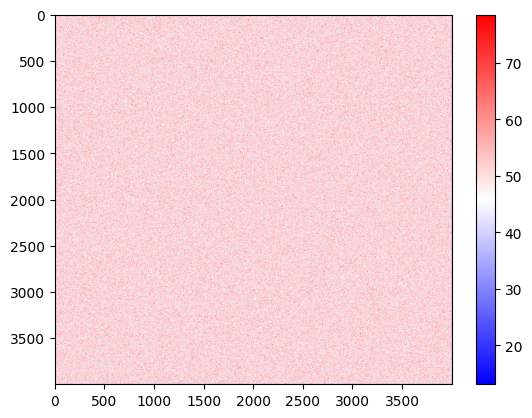

In [3]:
"📗 2D"
def generate_random_matrix(n_rows: int, n_cols: int, low: float = 0.0, high: float = 1.0,
                           device=device, dtype=torch.float32) -> torch.Tensor:
    """Generate a 2D torch matrix of random values in [low, high)."""
    if n_rows <= 0 or n_cols <= 0:
        raise ValueError("n_rows and n_cols must be positive integers.")
    if high <= low:
        raise ValueError("high must be greater than low.")
    return low + (high - low) * torch.rand((n_rows, n_cols), device=device, dtype=dtype)

def generate_patchy_matrix(
    n_rows: int,
    n_cols: int,
    device: str,
    min_val: float = 0.0,
    max_val: float = 1.0,
    smooth_radius: int = 16,) -> torch.Tensor:
    """
    Generate a spatially correlated random field.

    Args:
        n_rows: Height.
        n_cols: Width.
        device: Torch device.
        min_val: Minimum value in the output field.
        max_val: Maximum value in the output field.
        smooth_radius: Larger values produce larger patches.

    Returns:
        Tensor of shape (n_rows, n_cols).
    """
    x = torch.rand(1, 1, n_rows, n_cols, device=device)

    k = 2 * smooth_radius + 1
    x = F.avg_pool2d(
        x,
        kernel_size=k,
        stride=1,
        padding=smooth_radius,
    )

    x = x[0, 0]

    # Rescale from [0, 1] to [min_val, max_val].
    x = min_val + (max_val - min_val) * x

    return x

# arr_2d    = generate_random_matrix(50, 50, low=0.0, high=30)
arr_2d    = generate_patchy_matrix(4000, 4000, device=device, min_val=0.0, max_val=100, smooth_radius=2)

# donut test
# arr_2d = torch.zeros(20, 20)
# for i in range(20):
#     for j in range(20):
#         dist = ((i-10)**2 + (j-10)**2)**0.5
#         if 2.5 < dist < 4.0:
#             arr_2d[i, j] = 1.0
#         elif dist < 2.5:
#             arr_2d[i, j] = 0.1

arr_2d_np = arr_2d.numpy()

# start_gudhi_2d  = perf_counter()
# cc = CubicalComplex(dimensions=arr_2d_np.shape, top_dimensional_cells=arr_2d_np.flatten())
# cc.compute_persistence(homology_coeff_field=2) # default is 11, but 2 is faster for Z/2Z coefficients
# endtime_gudhi_2d= perf_counter()
# print(f"🧮 [🪷 gudhi] persistence of {arr_2d.shape[0]*arr_2d.shape[1]} y vals in {endtime_gudhi_2d - start_gudhi_2d:.4f} s")

# start_cripser_2d  = perf_counter()
# ph_2d             = cripser.compute_ph(arr_2d_np, maxdim=1)
# endtime_cripser_2d= perf_counter()
# print(f"🧮 [⚡️ cripser] persistence of {arr_2d.shape[0]*arr_2d.shape[1]} y vals in {endtime_cripser_2d - start_cripser_2d:.4f} s")

# def bench_cripser():
#     return cripser.compute_ph(arr_2d_np, maxdim=1)
# peak_cripser_mem = max(memory_usage(bench_cripser))
# print(f"💾 Peak RAM: {peak_cripser_mem:.2f} MiB")

# # Separate H0 and H1 diagrams
# h0_cripser = ph_2d[ph_2d[:, 0] == 0][:, 1:3]  # Keeps only [Birth, Death]
# h1_cripser = ph_2d[ph_2d[:, 0] == 1][:, 1:3]  # Keeps only [Birth, Death]

# # Print summary to verify profiles
# print(f"CRiPSER # H0: {len(h0_cripser)}, # H1: {len(h1_cripser)}")
# # print("First few H1 pairs:\n", h1_cripser[:3])

plt.imshow(arr_2d, aspect="auto", cmap="bwr")
plt.colorbar()
plt.show()

In [ ]:
"🪑🪑🪑benchmarking OTHER METHODS"

REGULAR, MIN, MAX, SADDLE = 0, 1, 2, 3

# Ready variables
arr_2d_np = arr_2d.detach().cpu().numpy().astype('float32')
clear_memory()

print(f"\n==================== RUNNING BASELINE BENCHMARKS (3x Trials) ====================")

# 2. Cripser Benchmark Setup
def run_cripser():
    return cripser.compute_ph(arr_2d_np, maxdim=1)

cripser_times = []
cripser_mems = []

for trial in range(3):
    clear_memory()
    start_cripser_2d = perf_counter()
    ph_2d = run_cripser()
    endtime_cripser_2d = perf_counter()
    cripser_times.append(endtime_cripser_2d - start_cripser_2d)
    
    peak_mem_cripser = max(memory_usage(run_cripser))
    cripser_mems.append(peak_mem_cripser)
    del ph_2d

print(f"🧮 [⚡️ cripser] Time:     {np.mean(cripser_times):.4f} s ± {np.std(cripser_times):.4f} s")
print(f"💾 [⚡️ cripser] Peak RAM: {np.mean(cripser_mems):.2f} MiB ± {np.std(cripser_mems):.2f} MiB")
print(f"CubicalRipser & {np.mean(cripser_times):.3f}$\\pm${np.std(cripser_times):.3f} & {np.mean(cripser_mems):.2f}$\\pm${np.std(cripser_mems):.2f} \\")

clear_memory()


# 1. GUDHI Benchmark Setup
def run_gudhi():
    cc = CubicalComplex(dimensions=arr_2d_np.shape, top_dimensional_cells=arr_2d_np.flatten())
    return cc.compute_persistence(homology_coeff_field=2)

gudhi_times = []
gudhi_mems = []

for trial in range(3):
    clear_memory()
    start_gudhi_2d = perf_counter()
    _ = run_gudhi()
    endtime_gudhi_2d = perf_counter()
    gudhi_times.append(endtime_gudhi_2d - start_gudhi_2d)
    
    peak_mem_gudhi = max(memory_usage(run_gudhi))
    gudhi_mems.append(peak_mem_gudhi)
    print(f"💾 [🪷 gudhi] Peak RAM: {peak_mem_gudhi:.2f} MiB")
    print(f"🧮 [🪷 gudhi] Time:     {endtime_gudhi_2d - start_gudhi_2d:.4f} s")

print(f"🧮 [🪷 gudhi] Time:     {np.mean(gudhi_times):.4f} s ± {np.std(gudhi_times):.4f} s")
print(f"💾 [🪷 gudhi] Peak RAM: {np.mean(gudhi_mems):.2f} MiB ± {np.std(gudhi_mems):.2f} MiB")
print(f"Gudhi & {np.mean(gudhi_times):.3f}$\\pm$ {np.std(gudhi_times):.3f} & {np.mean(gudhi_mems):.2f}$\\pm${np.std(gudhi_mems):.2f} \\")

clear_memory()

# 3. Dionysus 2 Benchmark Setup
# def run_dionysus():
#     f = dion.fill_freudenthal(arr_2d_np)
#     return dion.homology_persistence(f)

# dionysus_times = []
# dionysus_mems = []

# for trial in range(3):
#     clear_memory()
#     start_dionysus = perf_counter()
#     m = run_dionysus()
#     endtime_dionysus = perf_counter()
#     dionysus_times.append(endtime_dionysus - start_dionysus)
    
#     peak_mem_dionysus = max(memory_usage(run_dionysus))
#     dionysus_mems.append(peak_mem_dionysus)
#     del m

# clear_memory()

# print(f"🧮 [🦕 dionysus] Time:     {np.mean(dionysus_times):.4f} s ± {np.std(dionysus_times):.4f} s")
# print(f"💾 [🦕 dionysus] Peak RAM: {np.mean(dionysus_mems):.2f} MiB ± {np.std(dionysus_mems):.2f} MiB")
# print("================================================================================\n")

In [6]:
"our method 2d"
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from topo.persistence_2d import compute_h0_h1_fast, run_streaming_persistence, prepare_multi_chunk_wrapper

print(f"\n==================== WAY 1: GLOBAL (3x Trials) ====================")

global_times = []
global_mems = []

def bench_2d():
    return compute_h0_h1_fast(arr_2d)

# Warmup pass to eliminate initial JIT/Numba compilation overhead from stats
_ = bench_2d()
clear_memory()

for trial in range(1):
    clear_memory()
    start_our_2d = perf_counter()
    h0, h1 = compute_h0_h1_fast(arr_2d)
    endtime_our_2d = perf_counter()
    global_times.append(endtime_our_2d - start_our_2d)
    
    peak_mem_global = max(memory_usage(bench_2d))
    global_mems.append(peak_mem_global)
    
    if trial == 2:  # Save dimensions for reference report on last trial
        h0_len, h1_len = len(h0), len(h1)
    del h0, h1

print(f"🧮 [😎 ours global] Time:     {np.mean(global_times):.4f} s ± {np.std(global_times):.4f} s")
print(f"💾 [😎 ours global] Peak RAM: {np.mean(global_mems):.2f} MiB ± {np.std(global_mems):.2f} MiB")
# print(f"   ↳ # H0 pairs: {h0_len}, # H1 pairs: {h1_len}")
# print(f"Ours & {np.mean(global_times):.3f}$\\pm${np.std(global_times):.3f} & {np.mean(global_mems):.2f}$\\pm${np.std(global_mems):.2f} \\")

clear_memory()


print(f"\n==================== WAY 2: ROW-WISE CHUNK STREAMING (3x Trials) ====================")

m_chunks = 10
stream_times = []
stream_mems = []
stream_vms = []

def bench_streaming():
    dp = prepare_multi_chunk_wrapper(arr_2d, m_chunks=m_chunks)
    return run_streaming_persistence(dp)

# Warmup pass to eliminate JIT compilation on streaming loops
_ = bench_streaming()
clear_memory()

for trial in range(2):
    clear_memory()
    
    if trial == 0:
        print(f"📦 Simulating stream arrival of {m_chunks} horizontal cuts (Verbose logging on Trial 1)...")
    
    start_streaming_total = perf_counter()
    chunks = torch.tensor_split(arr_2d, m_chunks, dim=0)
    packed_chunk_data = []

    for idx, chunk in enumerate(chunks):
        start_chunk = perf_counter()
        chunk_package = prepare_multi_chunk_wrapper(chunk, m_chunks=1)
        packed_chunk_data.append(chunk_package)
        end_chunk = perf_counter()
        if trial == 0:
            print(f"  ↳ 🚰 [Chunk {idx+1}/{m_chunks}] Footprint {chunk.shape[0]}x{chunk.shape[1]} in {end_chunk - start_chunk:.4f}s")

    if trial == 0:
        print(f"⚙️  Executing interface stitching across boundaries and compiling final diagram...")
        
    data_package = prepare_multi_chunk_wrapper(arr_2d, m_chunks=m_chunks)
    h0_stream, h1_stream = run_streaming_persistence(data_package)

    end_streaming_total = perf_counter()
    stream_times.append(end_streaming_total - start_streaming_total)
    stream_vms.append(get_vms_mib())
    
    peak_mem_stream = max(memory_usage(bench_streaming))
    stream_mems.append(peak_mem_stream)
    
    if trial == 2:
        h0_stream_len, h1_stream_len = len(h0_stream), len(h1_stream)
        
    del h0_stream, h1_stream, data_package, packed_chunk_data, chunks

print(f"\n🧮 [🚰 streaming total] Time:     {np.mean(stream_times):.4f} s ± {np.std(stream_times):.4f} s")
print(f"💾 [🚰 streaming] Peak RAM:     {np.mean(stream_mems):.2f} MiB ± {np.std(stream_mems):.2f} MiB")
print(f"💾 [🚰 streaming] Virtual (VMS): {np.mean(stream_vms):.2f} MiB ± {np.std(stream_vms):.2f} MiB")
print(f" & {m_chunks}& {np.mean(stream_times):.3f}$\\pm${np.std(stream_times):.3f} & {np.mean(stream_mems):.2f}$\\pm${np.std(stream_mems):.2f} \\\\")

# Quick verification verification check against fresh global run
h0_validate, h1_validate = compute_h0_h1_fast(arr_2d)
print(f"\nStreamed Layout -> H0: {h0_stream_len} pairs | H1: {h1_stream_len} pairs")
print(f"Match Success? H0: {'✅' if h0_stream_len == len(h0_validate) else '❌'} | H1: {'✅' if h1_stream_len == len(h1_validate) else '❌'}")

del h0_validate, h1_validate
clear_memory()
print("=====================================================================\n")
# watershed gives basin labels directly
# labels = watershed(arr_2d.cpu().numpy(), connectivity=1) # each unique label = one basin = one minimum


==================== WAY 1: GLOBAL (3x Trials) ====================
🧮 [😎 ours global] Time:     4.8840 s ± 0.0000 s
💾 [😎 ours global] Peak RAM: 5602.38 MiB ± 0.00 MiB

==================== WAY 2: ROW-WISE CHUNK STREAMING (3x Trials) ====================
📦 Simulating stream arrival of 10 horizontal cuts (Verbose logging on Trial 1)...
  ↳ 🚰 [Chunk 1/10] Footprint 400x4000 in 0.0024s
  ↳ 🚰 [Chunk 2/10] Footprint 400x4000 in 0.0028s
  ↳ 🚰 [Chunk 3/10] Footprint 400x4000 in 0.0043s
  ↳ 🚰 [Chunk 4/10] Footprint 400x4000 in 0.0048s
  ↳ 🚰 [Chunk 5/10] Footprint 400x4000 in 0.0049s
  ↳ 🚰 [Chunk 6/10] Footprint 400x4000 in 0.0047s
  ↳ 🚰 [Chunk 7/10] Footprint 400x4000 in 0.0047s
  ↳ 🚰 [Chunk 8/10] Footprint 400x4000 in 0.0048s
  ↳ 🚰 [Chunk 9/10] Footprint 400x4000 in 0.0046s
  ↳ 🚰 [Chunk 10/10] Footprint 400x4000 in 0.0048s
⚙️  Executing interface stitching across boundaries and compiling final diagram...

🧮 [🚰 streaming total] Time:     11.4917 s ± 0.0649 s
💾 [🚰 streaming] Peak RAM:     5883.

NameError: name 'h0_stream_len' is not defined

In [ ]:
import psutil, os

def get_ram():
    """Returns current process RAM in MiB."""
    return psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# 1. Take initial RAM snapshot
ram_start = get_ram()
t0 = perf_counter()

# 2. Run your 1-line process
h0, h1 = compute_h0_h1_fast(arr_2d)

# 3. Take final snapshots
duration = perf_counter() - t0
ram_end = get_ram()

# 4. Print results
print(f"⏱️ Time: {duration:.4f}s")
print(f"📊 RAM Jump: {ram_start:.2f} MiB -> {ram_end:.2f} MiB (Delta: {ram_end - ram_start:.2f} MiB)")

In [ ]:
import shutil, pathlib

# delete numba cache
for p in pathlib.Path('.').rglob('__pycache__'):
    shutil.rmtree(p, ignore_errors=True)
for p in pathlib.Path('.').rglob('*.nbi'):
    p.unlink(missing_ok=True)
for p in pathlib.Path('.').rglob('*.nbc'):
    p.unlink(missing_ok=True)

print("cache cleared")